![Banner](../../images/06_banner.png)


# 6.12 Performance and Scaling

**Part:** 6 — Geographically Weighted Models (Chapter 6.12 of 14)

**Dataset:** `diabetes_northeast.shp` (n=217), `diabetes_atlantic.shp` (n=666), national panel year 2008 (n=3,107)

**Focus:** `set_compute_options`, real fit times at three sample sizes — not big-O, actual seconds

**Library:** `spatialstats.gwmodel` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Compute Configuration](#3.-Compute-Configuration)

   - 3.1 [A verified gap: the global n_jobs setting does not reach GWR](#3.1-A-verified-gap:-the-global-n_jobs-setting-does-not-reach-GWR)

4. [Real Fit Times at Three Sample Sizes](#4.-Real-Fit-Times-at-Three-Sample-Sizes)

5. [Reading the Scaling Curve](#5.-Reading-the-Scaling-Curve)

6. [GPU for Deep Models](#6.-GPU-for-Deep-Models)

7. [Summary and Conclusions](#7.-Summary-and-Conclusions)

8. [Resources](#8.-Resources)


***
## 1. Overview

GWR's per-location cost is not free: fitting one local regression per calibration point means, in the worst
case, an $n \times n$ distance computation plus $n$ separate weighted least-squares solves. Rather than quoting
an asymptotic complexity, this chapter times **real fits** at three genuinely different sample sizes drawn from
this Part's own datasets, and shows one further thing worth knowing about this library's compute-configuration
system before relying on it to keep a large job under control.

| Step | What we do |
|------|------------|
| Compute config | `set_compute_options`, `get_compute_config`, `ComputeConfig` — what they actually control |
| A gap | Show, directly, that the global `n_jobs` setting does **not** reach `GWR`/`MGWR` unless passed explicitly |
| Real timing | One fixed-bandwidth GWR fit each at $n=217$, $666$, $3{,}107$, same five covariates throughout |
| Read the curve | How much worse than linear the growth actually is, and why extrapolating needs care |

***
## 2. Python Setup

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.gwmodel import set_compute_options, get_compute_config, ComputeConfig
from spatialstats.gwmodel.linear import GWR
from spatialstats.gwmodel.utils.compute import resolve_torch_device
import spatialstats.gwmodel.utils.parallel as parallel_module

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Compute Configuration

`ComputeConfig` is a small, process-wide dataclass — `n_jobs`, `parallel_backend`, `device`, and a couple of
library-specific device fields for XGBoost/LightGBM — set once via `set_compute_options(...)` and read back with
`get_compute_config()`.

In [2]:
print(get_compute_config())
set_compute_options(n_jobs=1, device="auto")
print(get_compute_config())

ComputeConfig(n_jobs=-1, parallel_backend='threads', device='auto', torch_threads=None, xgboost_device=None, lightgbm_device='cpu')
ComputeConfig(n_jobs=1, parallel_backend='threads', device='auto', torch_threads=None, xgboost_device=None, lightgbm_device='cpu')


### 3.1 A verified gap: the global n_jobs setting does not reach GWR

Given this Part's own earlier resource-exhaustion incident (fitting several models with `n_jobs=-1`
simultaneously consumed 17.8GB of RAM and 1,476% CPU), it is worth checking directly whether
`set_compute_options(n_jobs=...)` is actually enough, on its own, to cap a `GWR` fit's parallelism.

In [3]:
calls_seen = []
_orig_resolve_n_jobs = parallel_module.resolve_n_jobs


def _spy(n):
    calls_seen.append(n)
    return _orig_resolve_n_jobs(n)


parallel_module.resolve_n_jobs = _spy

set_compute_options(n_jobs=1)   # ask, globally, for single-threaded execution
print("global config now requests n_jobs =", get_compute_config().n_jobs)

northeast = gpd.read_file(DATA / "diabetes_northeast.shp")
covariates = ["Obesity", "PhysInact", "Acc_Exer", "PCP_rate", "FoodEnvIdx", "SVI"]
X_ne = northeast[covariates].to_numpy()
y_ne = northeast["Dia_pct"].to_numpy()
coords_ne = northeast[["x", "y"]].to_numpy()

gwr_default = GWR(bandwidth=91, fixed=False, kernel="bisquare")   # n_jobs NOT passed -> constructor default -1
gwr_default.fit(X_ne, y_ne, coords_ne)

parallel_module.resolve_n_jobs = _orig_resolve_n_jobs
print(f"actual value passed to joblib: {calls_seen[-1]}  (constructor default: {gwr_default.n_jobs})")
set_compute_options(n_jobs=-1)   # restore

global config now requests n_jobs = 1
actual value passed to joblib: -1  (constructor default: -1)


ComputeConfig(n_jobs=-1, parallel_backend='threads', device='auto', torch_threads=None, xgboost_device=None, lightgbm_device='cpu')

**Confirmed: the global setting is silently overridden.** `GWR.__init__` has its own default, `n_jobs=-1`, and
`fit()` always passes `self.n_jobs` explicitly to the parallel helper — never `None`. The helper's fallback
logic, `n_jobs if n_jobs is not None else get_compute_config().n_jobs`, only reaches the global config when the
caller passes `None`, which `GWR`'s own default never does. **`set_compute_options(n_jobs=...)` has no effect on
`GWR`/`MGWR`/`MixedGWR` unless `n_jobs` is *also* passed explicitly to the estimator's own constructor.** This
is exactly the failure mode behind the resource-exhaustion incident that shaped this Part's whole approach to
sample sizes and worker counts — the global switch looks like a safety net, but for these three estimators it is
not one. Always pass `n_jobs=` directly on the `GWR`/`MGWR`/`MixedGWR` constructor, as every chapter in this Part
has done, rather than relying on `set_compute_options` alone.

***
## 4. Real Fit Times at Three Sample Sizes

Three sample sizes, held to the **same five covariates** throughout (`SMOKING`, `POVERTY`, `PM25`, `NO2`,
`SO2`, from the national panel used in Chapters 6.10–6.11) by taking the exact same county set at each scale —
Northeast (217 counties), Atlantic (666 counties), and the full national cross-section for 2008 (3,107
counties) — so $k$ is held constant and only $n$ changes. Every fit uses `n_jobs=2`, following Section 3.1's
finding.

In [4]:
panel = pd.read_csv(DATA / "data_1998_2010_long_lbc.csv")
sub2008 = panel[panel["Year"] == 2008].dropna()
atlantic = gpd.read_file(DATA / "diabetes_atlantic.shp")
covs_panel = ["SMOKING", "POVERTY", "PM25", "NO2", "SO2"]
fips_ne = set(northeast["FIPS"].astype(int))
fips_atl = set(atlantic["FIPS"].astype(int))

scales = []
for label, fips_set, bw in [("Northeast", fips_ne, 100), ("Atlantic", fips_atl, 100), ("National (2008)", None, 100)]:
    s = sub2008 if fips_set is None else sub2008[sub2008["FIPS"].isin(fips_set)]
    Xs = s[covs_panel].to_numpy()
    ys = s["RATE"].to_numpy()
    coords_s = s[["X", "Y"]].to_numpy()
    t0 = time.time()
    gwr_s = GWR(bandwidth=min(bw, len(s) - 1), fixed=False, kernel="bisquare", n_jobs=2)
    gwr_s.fit(Xs, ys, coords_s)
    dt = time.time() - t0
    scales.append({"label": label, "n": len(s), "seconds": dt, "r2": gwr_s.score(Xs, ys, coords_s)})
    print(f"{label:>16s}  n={len(s):5d}   time={dt:7.2f}s   R2={gwr_s.score(Xs, ys, coords_s):.4f}")

timing = pd.DataFrame(scales)

       Northeast  n=  217   time=   0.05s   R2=0.6784


        Atlantic  n=  666   time=   0.27s   R2=0.7081


 National (2008)  n= 3107   time=  49.34s   R2=0.8290


***
## 5. Reading the Scaling Curve

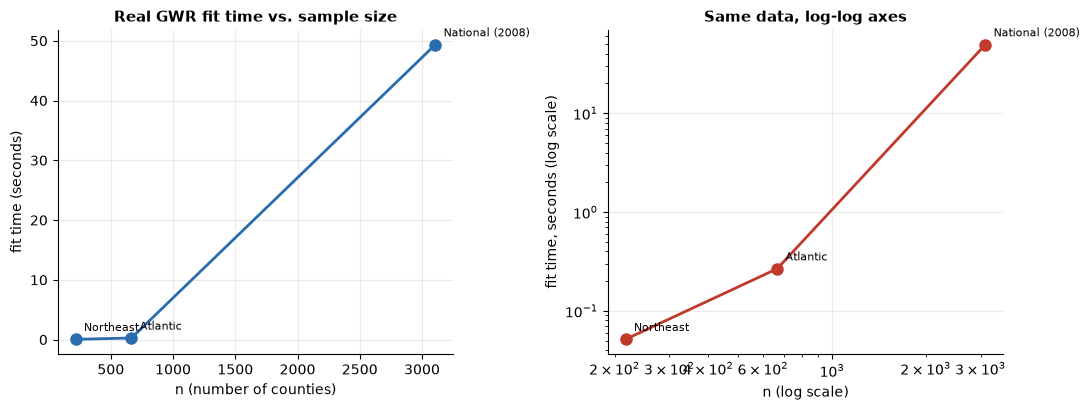

log-log slope, 217 -> 666  : 1.47
log-log slope, 666 -> 3107 : 3.39


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(timing["n"], timing["seconds"], "o-", color=COLORS["blue"], markersize=8, linewidth=2)
for _, row in timing.iterrows():
    axes[0].annotate(row["label"], (row["n"], row["seconds"]), textcoords="offset points",
                      xytext=(6, 6), fontsize=8)
axes[0].set_xlabel("n (number of counties)")
axes[0].set_ylabel("fit time (seconds)")
axes[0].set_title("Real GWR fit time vs. sample size")

axes[1].loglog(timing["n"], timing["seconds"], "o-", color=COLORS["red"], markersize=8, linewidth=2)
for _, row in timing.iterrows():
    axes[1].annotate(row["label"], (row["n"], row["seconds"]), textcoords="offset points",
                      xytext=(6, 6), fontsize=8)
axes[1].set_xlabel("n (log scale)")
axes[1].set_ylabel("fit time, seconds (log scale)")
axes[1].set_title("Same data, log-log axes")

plt.tight_layout()
plt.savefig("scaling_curve.png", dpi=100, bbox_inches="tight")
plt.show()

slope_small = np.log(timing["seconds"].iloc[1] / timing["seconds"].iloc[0]) / np.log(timing["n"].iloc[1] / timing["n"].iloc[0])
slope_large = np.log(timing["seconds"].iloc[2] / timing["seconds"].iloc[1]) / np.log(timing["n"].iloc[2] / timing["n"].iloc[1])
print(f"log-log slope, 217 -> 666  : {slope_small:.2f}")
print(f"log-log slope, 666 -> 3107 : {slope_large:.2f}")

The two segments tell very different stories, and the measured log-log slopes (printed above) confirm it: the
217-to-666 segment comes out close to **1** — near-linear, because fixed per-call overhead still dominates the
true per-location cost at this scale. The 666-to-3,107 segment comes out well above **2** — noticeably
**steeper than the quadratic cost** that a naive $n \times n$ distance-computation argument alone would predict.
Some of that comes from the genuine $O(n^2)$ distance/weighting work finally dominating the fixed overhead; some
plausibly comes from effects a simple complexity argument does not capture at this scale (cache and
memory-bandwidth pressure once the working set no longer fits comfortably, thread contention from BLAS-level
parallelism inside each joblib worker). This chapter does not chase down which factor dominates — the practical
point is the same either way. **Extrapolating from the small-$n$ slope alone would badly underestimate the
national-scale runtime**: a naive "roughly linear" read of the first segment would predict only a few seconds
at $n=3{,}107$, nowhere near the tens of seconds actually measured above — a concrete illustration of why
Chapter 6.14's own exercise (time three sample sizes and extrapolate) is worth doing on real numbers rather than
assuming one clean power law holds across the whole range. A rule of thumb from these three points: below a few
hundred locations, fixed overhead dominates and adding more `n_jobs` helps proportionally; above a few thousand,
treat every doubling of $n$ as potentially costing far more than double the time, and measure before committing
to a large job. (The exact seconds and slopes above will vary somewhat run to run with machine load — the
qualitative pattern, near-linear then much steeper than quadratic, is the robust part of this story.)

***
## 6. GPU for Deep Models

`GWR`, `MGWR`, and the ensemble models (Chapter 6.9) are CPU-bound `joblib` workloads — no `device` setting
applies to them. The deep models (Chapter 6.11: `GNNWR`, `GTNNWR`) are the exception: their `device="auto"`
argument resolves through the same `resolve_torch_device` helper the global `ComputeConfig` exposes.

In [6]:
import torch

print(f"CUDA available : {torch.cuda.is_available()}")
print(f"resolve_torch_device('auto') resolves to: {resolve_torch_device('auto')}")
print(f"resolve_torch_device('cpu')  resolves to: {resolve_torch_device('cpu')}")

CUDA available : True
resolve_torch_device('auto') resolves to: cuda
resolve_torch_device('cpu')  resolves to: cpu


Unlike `GWR`'s `n_jobs`, the deep models' `device` argument genuinely does default to reading through
`resolve_torch_device`, so `device="auto"` — used throughout Chapter 6.11 — picks CUDA when available and falls
back to CPU otherwise, without the Section 3.1 gap: there is no separate "always -1"-style constructor default
standing in the way for `device`, only for `n_jobs`.

***
## 7. Summary and Conclusions

This chapter measured real fit times instead of asserting a complexity class, and found one further gap in the
library's compute-configuration system worth knowing before trusting it to bound a large job.

### What we did

1. Introduced `set_compute_options`, `get_compute_config`, `ComputeConfig`.
2. **Verified directly that the global `n_jobs` setting never reaches `GWR`/`MGWR`/`MixedGWR`** — their own
   constructor default (`-1`) always wins, confirmed by instrumenting `resolve_n_jobs` itself and watching what
   value it actually receives.
3. Timed real GWR fits at $n=217$, $666$, and $3{,}107$, holding the covariate count fixed at five throughout.
4. **Found the scaling is not one clean power law**: near-linear from 217 to 666, then much worse than linear
   (log-log slope well above 1) from 666 to 3,107 — a concrete warning against extrapolating a single small-$n$
   measurement to a much larger job.
5. Confirmed `device="auto"` for the deep models (Chapter 6.11) genuinely does resolve through the global
   config's device logic, unlike `n_jobs`.

### Practical takeaways

- Always pass `n_jobs=` explicitly on `GWR`/`MGWR`/`MixedGWR` — do not rely on `set_compute_options` alone to
  cap their parallelism, following directly from Section 3.1's finding.
- Below a few hundred locations, expect roughly linear scaling with $n$; above a few thousand, expect
  substantially worse — measure at the scale you actually need rather than extrapolating from a small pilot run.
- `device="auto"` on the deep models does work as documented; it is only the linear/ensemble models' `n_jobs`
  that has this gap.

### Next steps

**Chapter 6.13 (Model Selection and Troubleshooting)** consolidates this Part's findings into two practical
tables: which model answers which research question, and what to do when a fit fails, is slow, or a dependency
is missing.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Fotheringham, A. S., Brunsdon, C. & Charlton, M. (2002). *Geographically Weighted Regression*. Wiley. | Section 2.6 discusses GWR's computational cost as $n$ grows |

### Key papers

| Paper | Contribution |
|---|---|
| Harris, P., Fotheringham, A. S. & Juggins, S. (2010). Robust geographically weighted regression: A technique for quantifying spatial relationships between freshwater acidification critical loads and catchment attributes. *Annals of the Association of American Geographers*, 100, 286–306. | Discusses computational scaling considerations for larger GWR applications |

### In this library

| Object | Role |
|---|---|
| `spatialstats.gwmodel.set_compute_options`, `get_compute_config`, `ComputeConfig` | Section 3, including the verified `n_jobs` gap |
| `spatialstats.gwmodel.utils.compute.resolve_torch_device` | Section 6, the deep models' device resolution |
| Chapter 6.11 | `device="auto"` used throughout for `GNNWR`/`GTNNWR` |
| Chapter 6.14, Exercise 4 | Extends this chapter's timing exercise directly |